# Crypto Signal Prediction with Nixtla timeGPT Anomaly Detection

This notebook demonstrates how to use Nixtla's timeGPT anomaly detection to generate crypto trading signals, following the structure of spike_hunter.

1. Import Required Libraries
Import pandas, numpy, requests, and Nixtla's timeGPT library or API client.

2. Define fetch_klines Function
Implement a function to fetch historical OHLCV data for a given crypto symbol and interval from Binance.

3. Preprocess Data for timeGPT
Format and clean the fetched klines data to match the input requirements for timeGPT anomaly detection.

4. Apply Nixtla timeGPT Anomaly Detection
Use the timeGPT anomaly detection method on the preprocessed data to identify anomalies in the price series.

5. Generate Crypto Signals Based on Anomalies
Create a function to interpret detected anomalies as trading signals (e.g., buy/sell/hold), similar to spike_hunter's logic.

6. Visualize Anomalies in Time Series
Plot the time series and highlight detected anomalies.

In [20]:
%pip install python-dotenv nixtla



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Using the following exogenous features: ['volume', 'quote_asset_volume', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']
INFO:nixtla.nixtla_client:Calling Anomaly Detector Endpoint...
INFO:nixtla.nixtla_client:Using the following exogenous features: ['volume', 'quote_asset_volume', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']
INFO:nixtla.nixtla_client:Calling Anomaly Detector Endpoint...


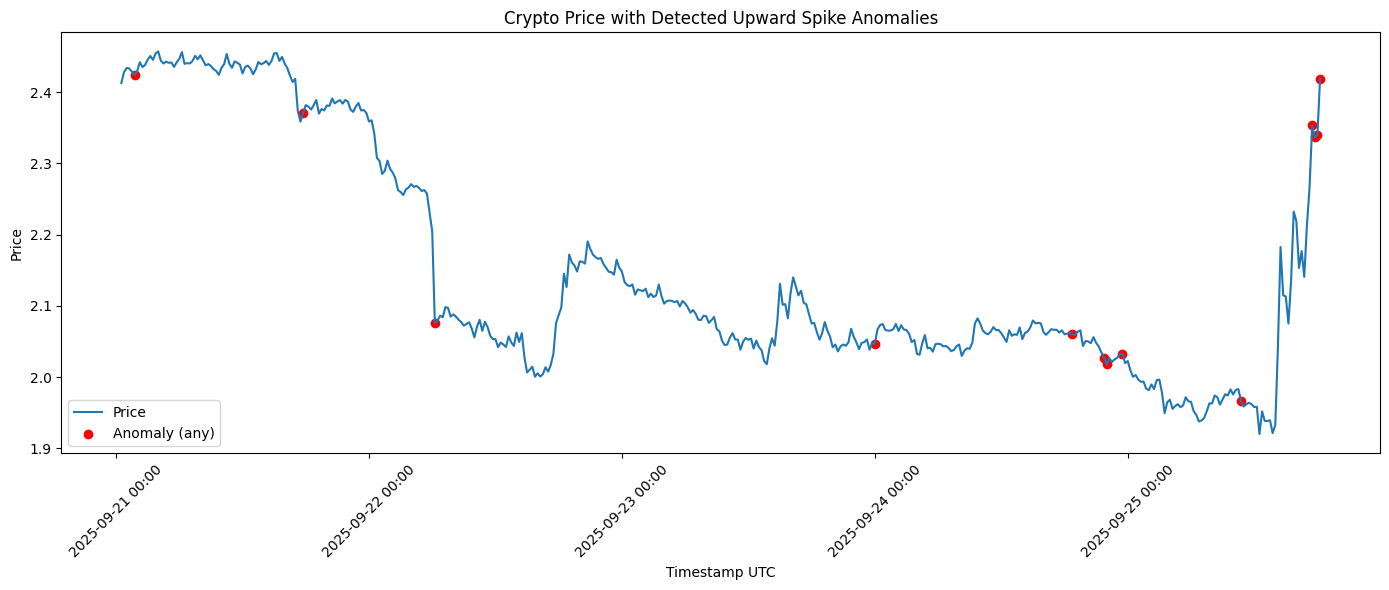

In [22]:
import pandas as pd
import requests
import os
from dotenv import load_dotenv
import time
from nixtla import NixtlaClient
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

load_dotenv()

timegpt_api_key = os.getenv("TIMEGPT_API_KEY", None)  # Set your API key here
symbol = "SPKTRY"
interval = "15m"
# Set end_time to a fixed timestamp: 22 Sep 2025 22:00:00 UTC (currently using 'now' so you can iterate)
end_time = int(time.time() * 1000)
# For 1h interval, 144 samples = 6 days (adjust still using 6 days window even if 15m data)
start_time = end_time - 6 * 24 * 60 * 60 * 1000  # last 6 days


def fetch_klines(symbol, interval, start_time, end_time, limit=1000):
    """
    Fetch historical klines (OHLCV) from Binance API.
    Args:
        symbol (str): e.g. 'BTCUSDT'
        interval (str): e.g. '5m', '1h'
        start_time (int): milliseconds
        end_time (int): milliseconds
        limit (int): max 1000
    Returns:
        pd.DataFrame: OHLCV data
    """
    url = "https://api.binance.com/api/v3/klines"
    all_klines = []
    while True:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_time,
            "endTime": end_time,
            "limit": limit,
        }
        response = requests.get(url, params=params)
        data = response.json()
        if not data:
            break
        all_klines.extend(data)
        if len(data) < limit:
            break
        start_time = data[-1][0] + 1  # next batch
    df = pd.DataFrame(
        all_klines,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "quote_asset_volume",
            "number_of_trades",
            "taker_buy_base_asset_volume",
            "taker_buy_quote_asset_volume",
            "ignore",
        ],
    )
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms")
    for col in [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
    ]:
        df[col] = df[col].astype(float)
    return df


def preprocess_klines_for_timegpt(df):
    """
    Prepare klines DataFrame for timeGPT anomaly detection, including volume as exogenous variable.
    Args:
        df (pd.DataFrame): Raw klines data
    Returns:
        pd.DataFrame: DataFrame with 'unique_id', 'ds' (timestamp), 'y' (target value), and 'volume' (exogenous variable)
    """
    # Use close price for anomaly detection, add volume as exogenous
    data = df[["close_time", "close", "volume", "quote_asset_volume", "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"]].copy()
    data = data.rename(columns={"close_time": "ds", "close": "y"})
    data["ds"] = pd.to_datetime(data["ds"])
    data["unique_id"] = symbol  # required for v2 endpoint
    return data


def detect_anomalies_timegpt(df, api_key, interval, level=99, horizon=0):
    """
    Use Nixtla v2 anomaly detection API to detect anomalies in the time series, with volume as exogenous variable.
    Args:
        df (pd.DataFrame): DataFrame with 'unique_id', 'ds', 'y', 'volume'
        api_key (str): Nixtla timeGPT API key
        interval (str): frequency string (e.g. '1h', '15m')
        level (int): confidence level (higher = stricter)
        horizon (int): forecast horizon (default 0)
    Returns:
        pd.DataFrame: DataFrame with anomaly scores and flags
    """
    nixtla_client = NixtlaClient(api_key=api_key)
    df["ds"] = df["ds"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    # Map Binance interval to pandas freq-ish tokens Nixtla expects (simple heuristic)
    freq_map = {
        '1m': 'min','3m': '3min','5m': '5min','15m': '15min','30m': '30min',
        '1h': 'H','2h': '2H','4h': '4H','6h': '6H','8h': '8H','12h': '12H','1d': 'D'
    }
    freq_token = freq_map.get(interval, 'H')
    anomalies_df = nixtla_client.detect_anomalies(
        df,
        time_col="ds",
        target_col="y",
        freq=freq_token,
        level=level,
    )

    # Ensure 'ds' is string in ISO format
    if pd.api.types.is_datetime64_any_dtype(df["ds"]):
        df["ds"] = df["ds"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")

    # Optional plotting (commented out to speed execution)
    # nixtla_client.plot(df, anomalies_df, time_col="ds", target_col="y")
    # nixtla_client.weights_x.plot.barh(x="features", y="weights")

    return anomalies_df


def generate_signals_from_anomalies(anomalies, spike_threshold_up=0.05, min_abs_move=None):
    """
    Generate trading signals restricting to UPWARD spikes only.

    Logic:
    1. Compute raw percent change (not absolute).
    2. Keep rows where anomaly == True AND pct_change >= spike_threshold_up.
    3. (Optional) If min_abs_move provided, also require absolute price delta >= min_abs_move.

    Args:
        anomalies (pd.DataFrame): Output from detect_anomalies_timegpt (must contain 'y' and 'anomaly').
        spike_threshold_up (float): Minimum positive percent change (e.g. 0.05 = +5%).
        min_abs_move (float|None): If set, require y - y.shift(1) >= this absolute move.

    Returns:
        pd.DataFrame with columns: ds, y, anomaly, signal, pct_change, abs_move
    """
    df = anomalies.copy()
    df['pct_change'] = df['y'].pct_change()  # can be negative or positive
    df['abs_move'] = df['y'].diff()
    # Upward spike filter
    cond = (df['anomaly']) & (df['pct_change'] >= spike_threshold_up)
    if min_abs_move is not None:
        cond &= (df['abs_move'] >= min_abs_move)
    df = df[cond].copy()
    df['signal'] = 'buy'  # Only upward spikes => buy
    return df[['ds','y','anomaly','signal','pct_change','abs_move']]


# 1. Fetch klines
df_klines = fetch_klines(symbol, interval, start_time, end_time)

# 2. Preprocess for timeGPT
df_timegpt = preprocess_klines_for_timegpt(df_klines)

# 3. Detect anomalies (stricter level)
anomalies = detect_anomalies_timegpt(df_timegpt, timegpt_api_key, interval)

# 4. Generate signals (UPWARD spikes only)
signals = generate_signals_from_anomalies(anomalies, spike_threshold_up=0.05)  # 5% upward spike

# Merge anomalies flags back for plotting full context
anoms_plot = anomalies.copy()
anoms_plot['ds'] = pd.to_datetime(anoms_plot['ds'])
anoms_plot['anomaly'] = anoms_plot['anomaly'].fillna(False)

plt.figure(figsize=(14,6))
plt.plot(anoms_plot['ds'], anoms_plot['y'], label='Price', color='#1f77b4')
plt.scatter(anoms_plot.loc[anoms_plot['anomaly'], 'ds'], anoms_plot.loc[anoms_plot['anomaly'], 'y'], color='red', label='Anomaly (any)')
plt.xlabel('Timestamp UTC')
plt.ylabel('Price')
plt.title('Crypto Price with Detected Upward Spike Anomalies')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()